# Maths into data science and AI 
# World Development indicators

# Introduction
In this notebook you explore the differences between high income and low income countries across a range of different measures.

You will first create plots that focus on a single numerical feature, grouped by other categorical features and then explore slices of the data.

This is similar to the data exploration you will need to carry out to explore the differences between cancelled and non-cancelled bookings for your practical task.

### Data context
This is an extract of development indicators for individual countries from World Bank. The data also includes geographical indicators, such as region.

### Data features
| **Feature** | **Description** | **Notes** |
| --- | --- | --- |
|**Country Name**             |||
|**Region**                   | Large scale region of the world                    |          |
|**Subregion**                |  More specific region                              |          |
|**Intermediate Region**      | Local region if given, otherwise same as subregion |          |
|**GNI**                      | Gross National Income                              |US dollars|
|**Internet use**             |Percentage of population who use the internet       |%         |
|**International tourism**    | Number of tourist arrivals per year                |          |
|**Life expectancy, female**  | Life expectancy at birth in years, female          |years     |
|**Life expectancy, male**    | Life expectancy at birth in years, male            |years     |
|**Physicians**               | Number of physicians per 1,000 people              |          |
|**Population**               | Total population                                   |          |
|**Women in national parliament**| Proportion of women in national parliaments     |%         |
|**Tertiary education, female**| Gross enrolment ratio for tertiary school, female |%         |
|**Tertiary education, male** | Gross enrolment ratio for tertiary school, male    |%         |
|**Greenhouse gas emissions** | Emissions CO2 equivalent                           |kilotons  |
|**High Income Economy**      | Whether the GNI per capita exceeds 2020 World Bank threshold of $12,696| Yes/No|



## Importing libraries and data

### Importing the libraries

In [ ]:
# import pandas 
import pandas as pd

# import seaborn and set the display style to "talk"
import seaborn as sns
sns.set_context("talk")

### Importing the data

In [ ]:
# import the data
wdi_data = pd.read_csv('/kaggle/input/world-demographic-indicators-extract/wdi_wide.csv')

# display the data set to check
wdi_data.head()

## Preparing the data and feature engineering

In [ ]:
# display the size of the data set and the data types
wdi_data.info()

In [ ]:
# get the summary statistics for all the numerical features
wdi_data.describe()

The `High Income Economy` feature is a categorical feature that is represented as a number in the original data set. It will be more helpful to have this as a text feature too. The code below creates a new text feature: `High Income` 

In [ ]:
# Create a new feature `High Income` from `High income economy` that has values No or Yes
wdi_data['High Income']=wdi_data['High Income Economy'].replace({0: 'No', 1: 'Yes'})

# display to check
wdi_data

The code in the boxes below creates GNI and emissions per person in the population:

In [ ]:
# Divide GNI by population, round it the nearest cent, and assign it to a new feature
wdi_data['GNI per capita'] = (wdi_data['GNI'] / wdi_data['Population']).round(2)
wdi_data['GNI per capita']

# Exploring Numerical Features

The groupby table below shows the mean of different numerical features in the data set. 

Use the table to identify interesting numerical features and then explore those with visualisations and summary statistics

In [ ]:
# create a list of the features to be explored
features=['Internet use', 'International tourism', 'Life expectancy, female', 'Life expectancy, male', 'Physicians', 'Population', 'Women in national parliament', 'Tertiary education, female', 'Tertiary education, male', 'Greenhouse gas emissions', 'High Income Economy', 'GNI per capita']

# use group by to get the means of these for low and high income
wdi_data.groupby('High Income')[features].mean().round(2)

## Using catplot for box plots and violin plots

In [ ]:
# create box plots for Life,expectancy female split by region and economy type
sns.catplot(data=wdi_data, kind='box',x='Life expectancy, female',y='Region', hue='High Income',aspect=2);

In [ ]:
# create box plots for Life,expectancy female split by region and economy type
sns.catplot(data=wdi_data, kind='violin',x='Life expectancy, female',y='Region', hue='High Income',split=True,aspect=2);

## Creating KDE plots with `displot`

A _kernel density estimation_ plot smoothes out the histogram to give an estimate of what the continuous distribution looks like.

### How does the distribution of life expectancy differ between high and low income economies?

You can use the `hue` parameter to draw separate curves for high and low income economies.

In [ ]:
# create a kde plot with one curve for each income category
# hue='High Income Economy' - draw separate curves for the two subsets
sns.displot(data=wdi_data, kind='kde', x='Life expectancy, female', hue='High Income', aspect=2);

## Task 1:

* Create box, violin and kde plots for **'Life expectancy, male'**. Separate these by type of economy.
* Add a short observation using markdown:
  - How do high and low income economies differ?
  - How do the regions differ?
  - Are the differences more significant for male or female life expectancy?
* Check your answers against the images below.

In [ ]:
# Code block for box plot


In [ ]:
# Code block for violin plot


In [ ]:
# Code block for kde


### Add your thoughts by double clicking this markdown:

### Check your answers:

You should have the following:
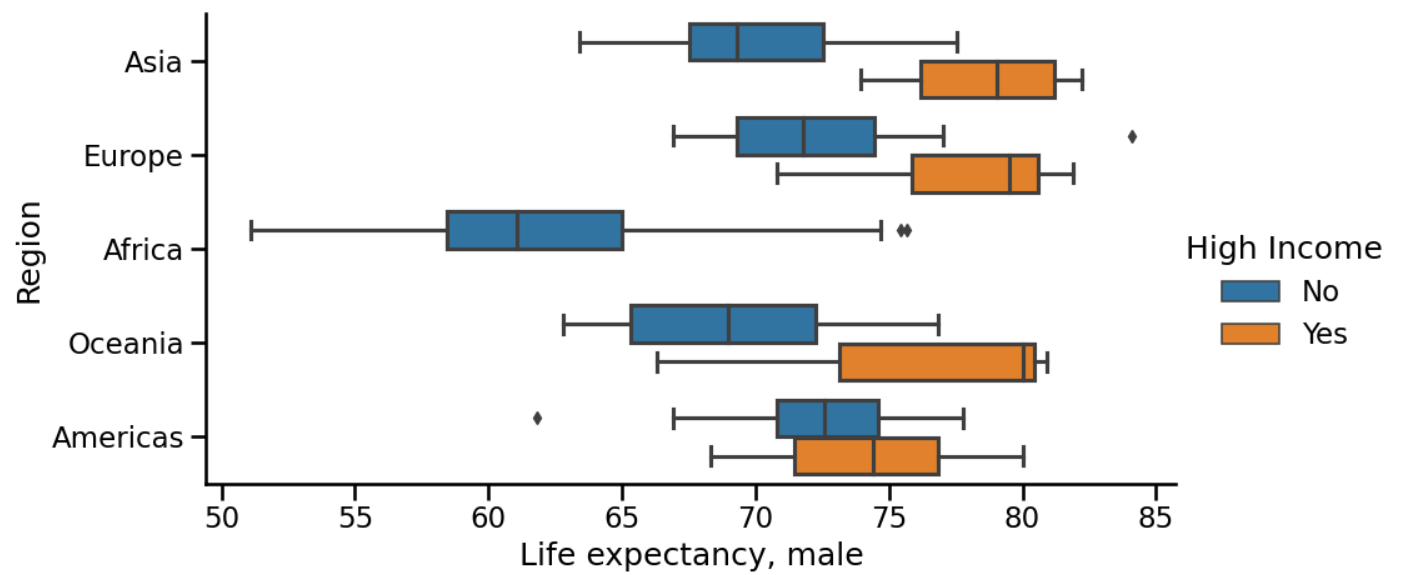
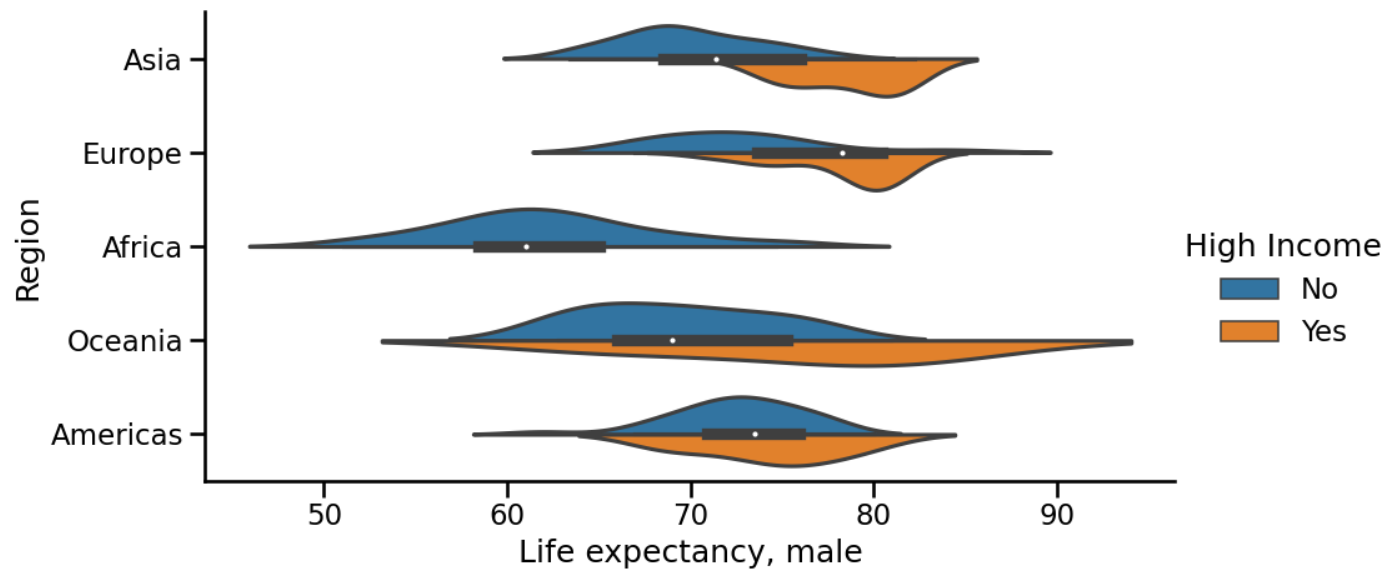
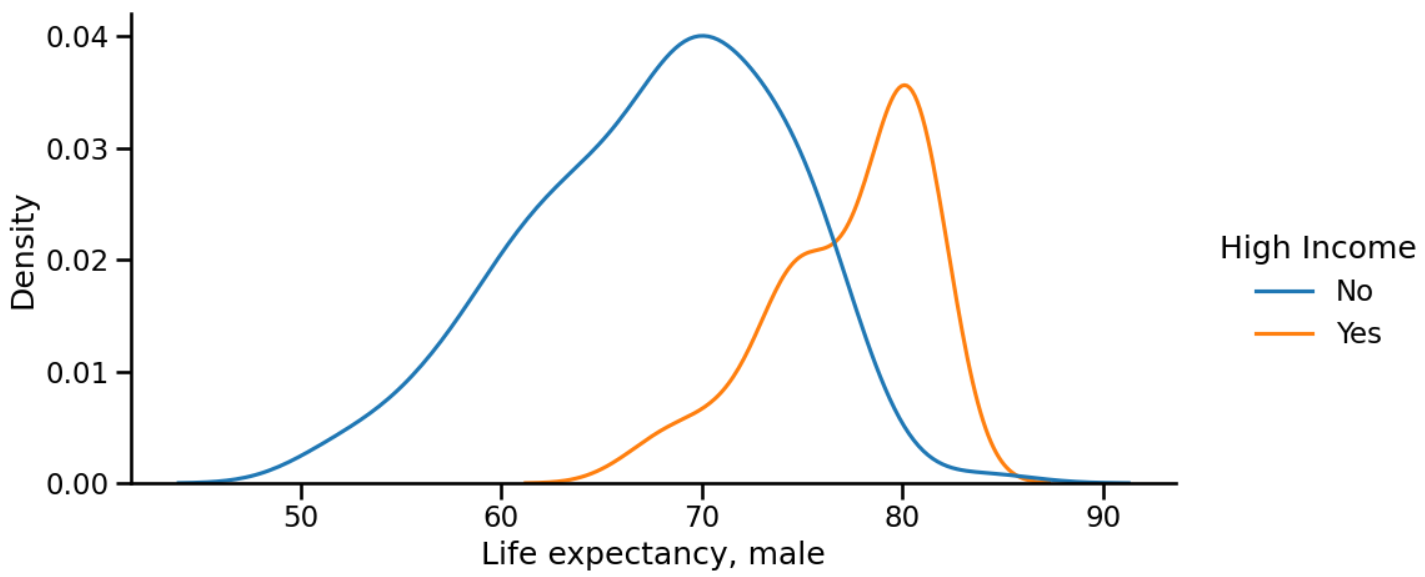

# Exploring categorical features

The code below can be used to examine the differences in a categorical feature such as region.
Use another categorical feature from the data set to create crosstabs and displots to examine the differences in high and low income economies

## Using `value_counts`

### How many countries are there in each region?

In [ ]:
wdi_data['Region'].value_counts()

### How many high income economies are there?

In [ ]:
wdi_data['High Income'].value_counts()

## Using `crosstab`

The `pd.crosstab` function in pandas produces a two-way table.

### Where are the high income economies?

In [ ]:
# display a 2-way table
pd.crosstab(wdi_data['High Income'], wdi_data['Region'])

In [ ]:
# bar chart split by a category (frequencies)
sns.displot(data=wdi_data, x='Region', hue='High Income', multiple='stack', aspect=2);

In crosstabs and bar charts you can also display the data by proportions.

In [ ]:
# two-way table (proportions)
pd.crosstab(wdi_data['High Income'], wdi_data['Region'], normalize='columns')

In [ ]:
# bar chart split by a category (proportions)
sns.displot(data=wdi_data, x='Region', hue='High Income', stat='proportion', multiple='fill',aspect=2);

### Creating a categorical feature
The code below creates a categorical feature from population size.

In [ ]:
# create 'bins' and 'labels'
bins = [0,1000000, 10000000, 100000000, 10000000000]
labels = ['Microstate', 'Small', 'Medium', 'Large']

# create a new feature based on the bins and labels
wdi_data['Population Size'] = pd.cut(wdi_data['Population'], bins = bins, labels = labels)

# display to check
wdi_data

## Task 2:

Use the category created above to 
* Use .value_counts() to explore the distribution of population size,
* Create a crosstab to compare high income economies with the population size category,
* create a bar chart split by category of the proportion of high income economies,
* Summarise your findings in a markdown cell

### Extension

Similarly create and explore another categorical feature.


In [ ]:
# use value_counts() to find the number of countries in each population size category


In [ ]:
# Crosstab between economy type and population size categories

In [ ]:
# Bar chart for the population size split by economy type


### Add your comments here:

### Check your answers

There are 69 small and 76 medium countries.

32.8% (22) of the high income economies are Microstates and only about 3% (2) are Large

The proportion bar chart should look like:
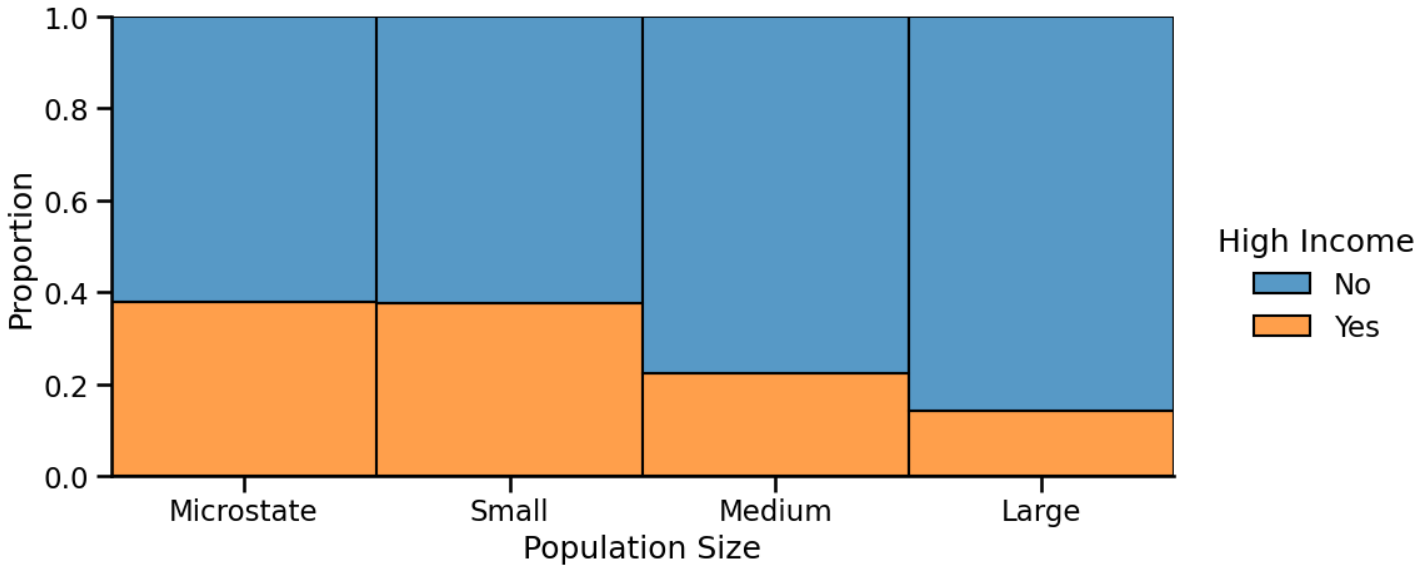



# Slicing the data

The code below takes a slice for regions either in the Americas or in Europe, then numerical features in these regions can be explored

In [ ]:
# create a slice for the Europe and Americas (done using | for 'or')
euro_americas_data = wdi_data[(wdi_data['Region'] == 'Americas') | (wdi_data['Region'] == 'Europe') ].copy()

# display to check
euro_americas_data

In [ ]:
# create a kde plot with one curve for each income category
# hue='High Income Economy' - draw separate curves for the two subsets
sns.displot(data=euro_americas_data, kind='kde', x='Life expectancy, female', hue='High Income', aspect=2);

### Task 3
* Add your own code boxes to create a slice of data which contains both Microstates and Small countries.
* Create visualisations for Life expectancy, female
* Consider the differences between the economy types in these types of countries. Summarise your findings in a markdown cell
  

### Check your answers
There should be 127 rows in a slice of both Microstates and Small countries

A kde plot split by either economy or Population size should look like:
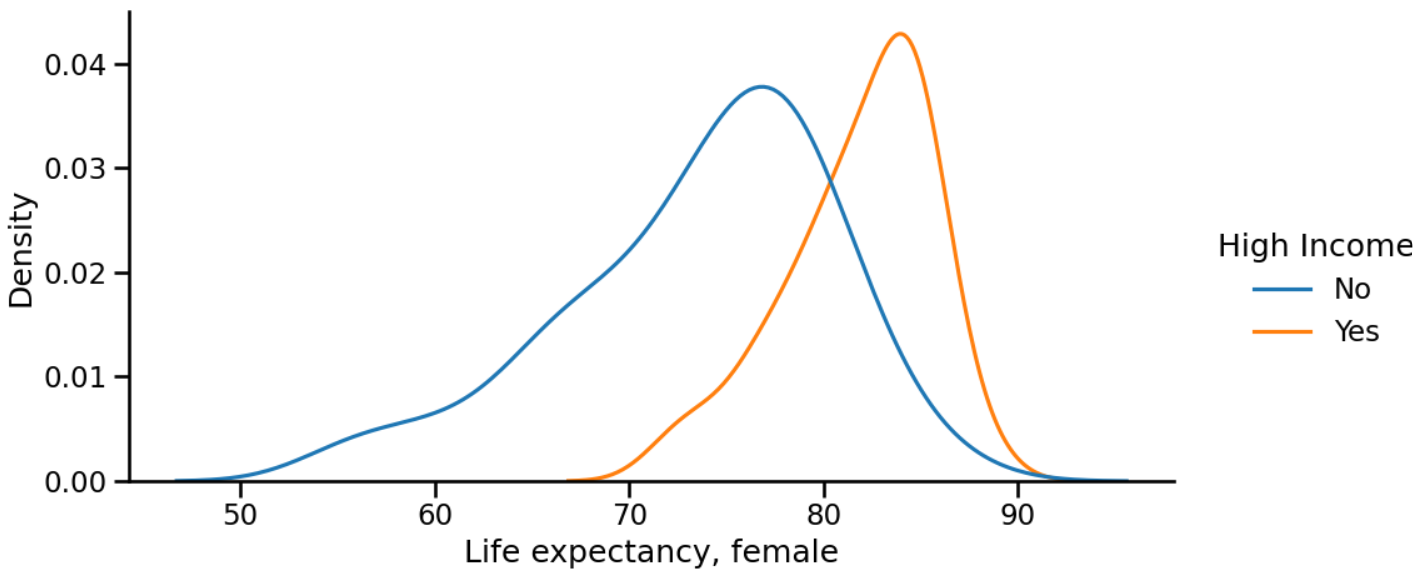
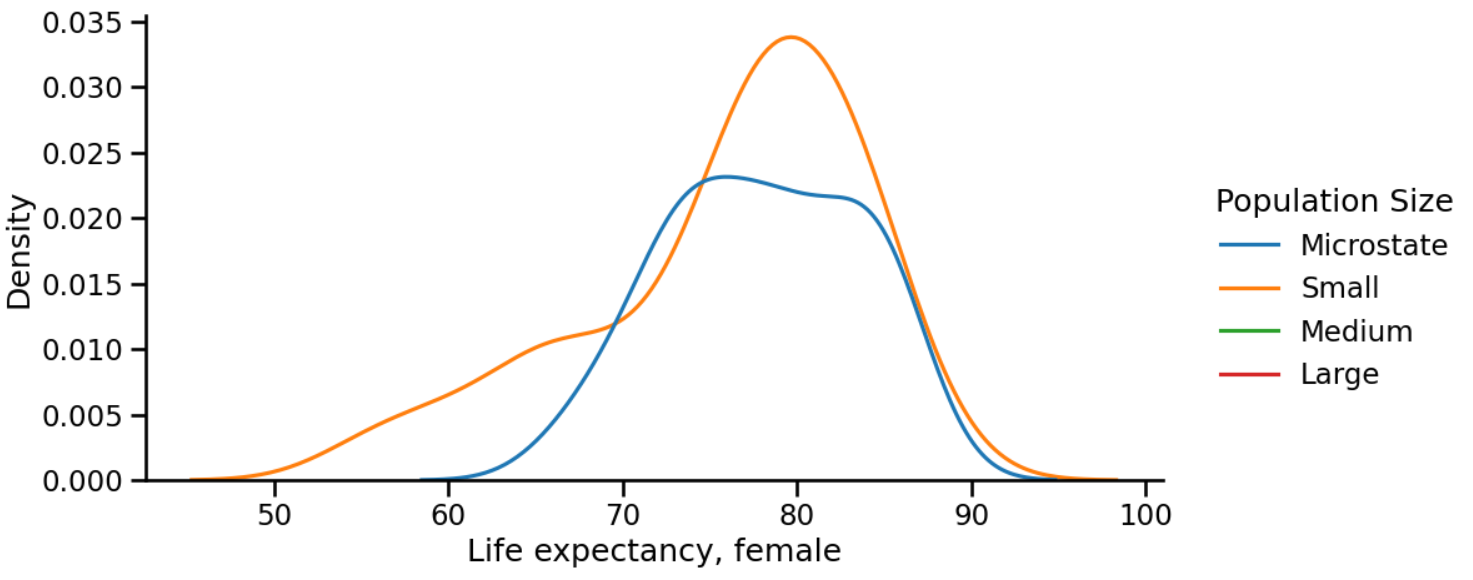

# Appendix: setting titles and axes
You can set the title of the visualisation and the axes, as well as defining the range of values on each axes. The code below gives an example of this.

In [ ]:
# plot the visualisation
plot = sns.displot(data=wdi_data, x='Life expectancy, female', aspect=2);

# Label the axes and show the plot
plot.set(xlim=(50,90),xlabel="Female life expectancy (years)", ylabel="Frequency", title="Average female life expectancy")
plot;